# scCS Tutorial — Pairwise Condition Comparison
## Multi-Condition Commitment Score Analysis with `PairScorer`

This notebook demonstrates the **multi-condition analysis** workflow in scCS v0.7.0.

We artificially split the pancreas dataset into two groups:
- **"high_velocity"** — cells with above-median RNA velocity magnitude (stronger commitment signal)
- **"low_velocity"** — cells with below-median RNA velocity magnitude (weaker commitment signal)

This simulates a treatment effect where one condition drives stronger fate commitment.

### Three-tier analysis framework

| Tier | What it answers | Key functions |
|------|----------------|---------------|
| **Tier 1** | What are the commitment scores per condition? | `score_all_conditions()`, `plot_star_grid()` |
| **Tier 2** | Is the difference statistically significant? | `compute_delta_CS()`, `compare_conditions()`, `plot_affinity_distributions()` |
| **Tier 3** | Does the trajectory shift between conditions? | `fit_mixed_model()`, `trajectory_shift()`, `plot_trajectory_shift()` |

### Reference
Kriukov et al. (2025) *Single-cell transcriptome of myeloid cells in response to transplantation of human retinal neurons reveals reversibility of microglial activation*


## 1. Setup and data loading

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
try:
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
except ImportError:
    pass

import scCS

print(f"scCS version: {scCS.__version__}")

sc.settings.verbosity = 1
scv.settings.verbosity = 1

# --- Tutorial display helpers (compact tables instead of per-fate loops) ---
pd.set_option("display.max_rows", 25)
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 160)


def _stack_drivers_by_condition(driver_dicts, n_per_fate=5, cols=None):
    """Stack {condition: {fate: DataFrame}} into one tidy long-form table.

    Adds ``condition`` and ``fate`` columns at the front; shows top
    ``n_per_fate`` rows per (condition, fate) group.
    """
    out = []
    for cond, fate_dict in driver_dicts.items():
        for fate, df in fate_dict.items():
            if df is None or len(df) == 0:
                continue
            block = df.head(n_per_fate).copy()
            block.insert(0, "fate", fate)
            block.insert(0, "condition", cond)
            out.append(block)
    if not out:
        return pd.DataFrame()
    big = pd.concat(out, ignore_index=True)
    if cols is not None:
        keep = ["condition", "fate"] + [c for c in cols if c in big.columns]
        big = big[keep]
    return big


def _stack_enrichment_by_condition(enrichment_dicts, n_per_group=3):
    """Flatten {condition: {fate: {direction: df}}} into one tidy table."""
    rows = []
    for cond, fate_results in enrichment_dicts.items():
        for fate, dir_results in fate_results.items():
            for direction in ("up", "down"):
                df = dir_results.get(direction, None)
                if df is None or df.empty:
                    continue
                top = df.head(n_per_group).copy()
                top.insert(0, "direction", direction)
                top.insert(0, "fate", fate)
                top.insert(0, "condition", cond)
                rows.append(top)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def _driver_overlap(per_cond_drivers, n_top=10, gene_col="gene"):
    """Build a fate x gene x condition presence matrix from {cond: {fate: df}}."""
    rows = []
    conds = list(per_cond_drivers.keys())
    if not conds:
        return pd.DataFrame()
    fates = list(next(iter(per_cond_drivers.values())).keys())
    for fate in fates:
        sets = {}
        for cond in conds:
            df = per_cond_drivers[cond].get(fate)
            if df is None or len(df) == 0 or gene_col not in df.columns:
                sets[cond] = set()
            else:
                sets[cond] = set(df.head(n_top)[gene_col].astype(str))
        all_genes = sorted(set.union(*sets.values())) if sets else []
        for g in all_genes:
            row = {"fate": fate, "gene": g}
            for cond in conds:
                row[cond] = g in sets[cond]
            row["n_conds"] = sum(row[c] for c in conds)
            row["shared_all"] = row["n_conds"] == len(conds)
            rows.append(row)
    return pd.DataFrame(rows)


scCS version: 0.7.4


In [2]:
# Load the pancreas dataset
adata = scv.datasets.pancreas()

# Standard preprocessing
import inspect as _inspect
_fn_sig = _inspect.signature(scv.pp.filter_and_normalize).parameters
if "n_top_genes" in _fn_sig:
    scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
else:
    # scvelo builds without n_top_genes: do filter_and_normalize then HVG.
    # Use flavor="cell_ranger" not the default "seurat": seurat passes
    # int n_bins to pd.cut on log-dispersions which contain +/-inf for
    # low-mean genes — pandas >= 2.2 rejects this with ValueError.
    # cell_ranger uses explicit bin edges including +/-inf and is
    # robust across pandas/py versions (scCS changelog v0.7.4).
    scv.pp.filter_and_normalize(adata, min_shared_counts=20)
    sc.pp.highly_variable_genes(
        adata, n_top_genes=2000, subset=True, flavor="cell_ranger"
    )
sc.pp.neighbors(adata)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

print(adata)

AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'highly_variable_genes', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'


In [3]:
# Run RNA velocity (dynamical model)
scv.tl.recover_dynamics(adata, n_jobs=32)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata)
scv.tl.velocity_pseudotime(adata)

print("Velocity computed.")

  0%|          | 0/1163 [00:00<?, ?gene/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=4708) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/emil/miniforge3/envs/lab-py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=4708) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Velocity computed.


## 2. Create artificial condition split

We split cells into two groups based on their **RNA velocity magnitude**:
- **high_velocity** — cells with above-median velocity magnitude
- **low_velocity** — cells with below-median velocity magnitude

This simulates a scenario where a treatment (e.g., a drug or genetic perturbation)
increases the strength of fate commitment signals.

> In a real experiment, `condition_obs_key` would point to a column like `'treatment'`,
> `'genotype'`, or `'time_point'` already present in `adata.obs`.


In [4]:
# Compute per-cell velocity magnitude from the velocity layer
velocity_matrix = adata.layers["velocity"]  # shape: (n_cells, n_genes)
# Use RMS across genes as a per-cell magnitude proxy
vel_magnitude = np.sqrt(np.nanmean(velocity_matrix ** 2, axis=1))

# Split at the median
median_mag = np.median(vel_magnitude)
adata.obs["condition"] = np.where(
    vel_magnitude >= median_mag, "high_velocity", "low_velocity"
)

# Also create a fake replicate column (for mixed model demo)
# In practice this would be biological replicates / samples
np.random.seed(42)
adata.obs["sample"] = np.random.choice(
    ["rep1", "rep2", "rep3"], size=adata.n_obs
)

print("Condition distribution:")
print(adata.obs["condition"].value_counts())
print("\nSample distribution:")
print(adata.obs["sample"].value_counts())

Condition distribution:
condition
high_velocity    1848
low_velocity     1848
Name: count, dtype: int64

Sample distribution:
sample
rep1    1282
rep2    1224
rep3    1190
Name: count, dtype: int64


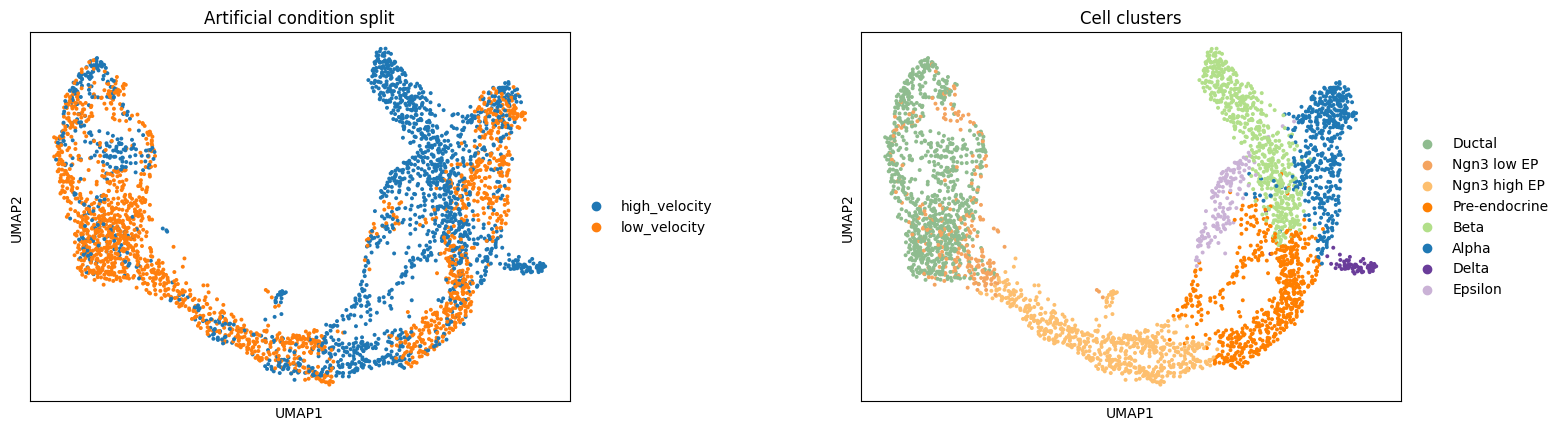

In [5]:
# Visualize the split on UMAP
sc.pl.umap(adata, color=["condition", "clusters"], ncols=2, wspace=0.4,
           title=["Artificial condition split", "Cell clusters"])

In [6]:
# Confirm both conditions contain bifurcation + terminal fate cells
for cond in ["high_velocity", "low_velocity"]:
    sub = adata[adata.obs["condition"] == cond]
    clusters_present = sub.obs["clusters"].unique().tolist()
    print(f"\n{cond}: {sub.n_obs} cells")
    print(f"  Clusters: {sorted(clusters_present)}")


high_velocity: 1848 cells
  Clusters: ['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine']

low_velocity: 1848 cells
  Clusters: ['Alpha', 'Beta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine']


## 3. Initialize `PairScorer`

`PairScorer` wraps `SingleScorer` and builds a **shared embedding**
on pooled data from all conditions.  This ensures that arm geometry is identical
across conditions — a prerequisite for valid cross-condition comparison.

Key parameters:
- `condition_obs_key` — column in `adata.obs` with condition labels
- All other parameters are identical to `SingleScorer`


In [7]:
mscorer = scCS.PairScorer(
    adata,
    root="Pre-endocrine",
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    condition_obs_key="condition",   # our artificial split
    obs_key="clusters",
    n_angle_bins=36,
    sector_method="centroid",
)

[scCS] PairScorer initialized.
       Conditions (2): ['high_velocity', 'low_velocity']
       Root: 'Pre-endocrine', Branches: ['Alpha', 'Beta', 'Delta', 'Epsilon']


## 4. Build the shared star embedding

The embedding is built on **all cells pooled** across conditions.
This guarantees that the arm directions are the same for both conditions.

We then fix arm coverage using subset-local pseudotime.
For multi-condition analysis, we use `scale_01=False` to preserve
absolute pseudotime ordering across conditions.


In [8]:
# Build shared embedding on pooled data
mscorer.build_embedding(
    ordering_metric="pseudotime",
    arm_scale=10.0,
    jitter=0.3,
)

# Fix arm coverage — use scale_01=False for cross-condition comparability
mscorer.refit_pseudotime(scale_01=True)

print("Shared embedding built.")
print(f"Cells in embedding: {mscorer.adata_sub.n_obs}")
print("Condition distribution in embedding:")
print(mscorer.adata_sub.obs["condition"].value_counts())

[scCS] Building SHARED embedding on pooled data (3696 cells, 2 conditions)...
[scCS] Building star embedding: root='Pre-endocrine', k=4 fates, metric='pseudotime'
[scCS] Subsetting: 1876 / 3696 cells kept
       (1820 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Epsilon: 142 cells (fate)
       Pre-endocrine: 592 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1876, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Delta': 180.0, 'Epsilon': 270.0}
[scCS] Star embedding stored in scorer.adata_sub.obsm['X_sccs']. (1876 cells)
[scCS] Recomputing pseudotime on subset (1876 / 3696 cells)...
[scCS] Used scanpy DPT (with diffmap) as pseudotime fallback.
[scCS] Subset pseudotime scaled to [0, 1].
[scCS] Subset pseudotime stored in adata_sub.obs['sccs_pseudotime']. Range: [0.000, 1.000]
[scCS] Rebuilding star embedding with subset-local pseudotime...
[scCS] Subsetting

## 5. Fit the shared FateMap

In [9]:
mscorer.fit()

[scCS] Root cluster 'Pre-endocrine': 592 cells, centroid=(-0.00, -0.00)
[scCS]   Fate 'Alpha': 481 cells, centroid=(3.51, -0.01)
[scCS]   Fate 'Beta': 591 cells, centroid=(0.03, 4.38)
[scCS]   Fate 'Delta': 70 cells, centroid=(-4.75, -0.05)
[scCS]   Fate 'Epsilon': 142 cells, centroid=(-0.02, -2.55)
[scCS] FateMap built: k=4 fates
[scCS] Projecting velocity via scVelo on full adata → slicing to subset...
[scCS] Velocity projected. Shape: (1876, 2)
FateMap  (root='Pre-endocrine', k=4)
  Cluster key : 'clusters'
  Root cells  : 592
  Root centroid: (-0.005, -0.003)
  Fate 0: 'Alpha'  n_cells=481  centroid=(3.51, -0.01)  arm_angle=0.0°
  Fate 1: 'Beta'  n_cells=591  centroid=(0.03, 4.38)  arm_angle=90.0°
  Fate 2: 'Delta'  n_cells=70  centroid=(-4.75, -0.05)  arm_angle=180.0°
  Fate 3: 'Epsilon'  n_cells=142  centroid=(-0.02, -2.55)  arm_angle=270.0°


PairScorer(root='Pre-endocrine', branches=['Alpha', 'Beta', 'Delta', 'Epsilon'], conditions=['high_velocity', 'low_velocity'], status='fitted')

## Tier 1: Score each condition on the shared embedding

`score_all_conditions()` computes commitment scores separately for each condition,
using the shared embedding and FateMap.  Each condition's cells are masked from
the shared `adata_sub`.


In [10]:
# Score all conditions
results = mscorer.score_all_conditions(
    cell_level=True,
    k_nn=15,
    n_bootstrap=200,   # bootstrap CI per condition
    bootstrap_ci=0.95,
    verbose=True,
)


[scCS] Scoring condition: 'high_velocity' (1249 cells)...
[scCS] Computing bootstrap CI (n=200)...
=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.6209  [aggregate velocity-mass balance]
    Mean cell entropy:            0.9361  [per-cell average, k-way]
    Per-fate cell entropy:
      Alpha: 0.8246
      Beta: 0.8608
      Delta: 0.7541
      Epsilon: 0.6399
    NN-smoothed entropy (k=15):  mean=0.9547  [per-cell, stored in adata_sub.obs['cs_nn_entropy']]

  Commitment vector (normalized):
    Alpha: 0.1490
    Beta: 0.7267
    Delta: 0.0663
    Epsilon: 0.0580

  Pairwise nCS matrix:
            Alpha      Beta     Delta   Epsilon
Alpha    1.000000  0.539098  0.756585  1.443795
Beta     1.854951  1.000000  1.403429  2.678169
Delta    1.321728  0.712540  1.000000  1.908304
Epsilon  0.692619  0.373389  0.524026  1.000000

  Bootstrap 95% CI on nCS (n=200):
    CI low:
         Alpha  

In [11]:
# Compare nCS matrices side by side
for cond, res in results.items():
    print(f"\n=== {cond} ===")
    print(pd.DataFrame(
        res.pairwise_nCS,
        index=res.fate_names,
        columns=res.fate_names
    ).round(3))


=== high_velocity ===
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.539  0.757    1.444
Beta     1.855  1.000  1.403    2.678
Delta    1.322  0.713  1.000    1.908
Epsilon  0.693  0.373  0.524    1.000

=== low_velocity ===
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.187    0.0    0.730
Beta     5.358  1.000    0.0    3.914
Delta      inf    inf    1.0      inf
Epsilon  1.369  0.255    0.0    1.000


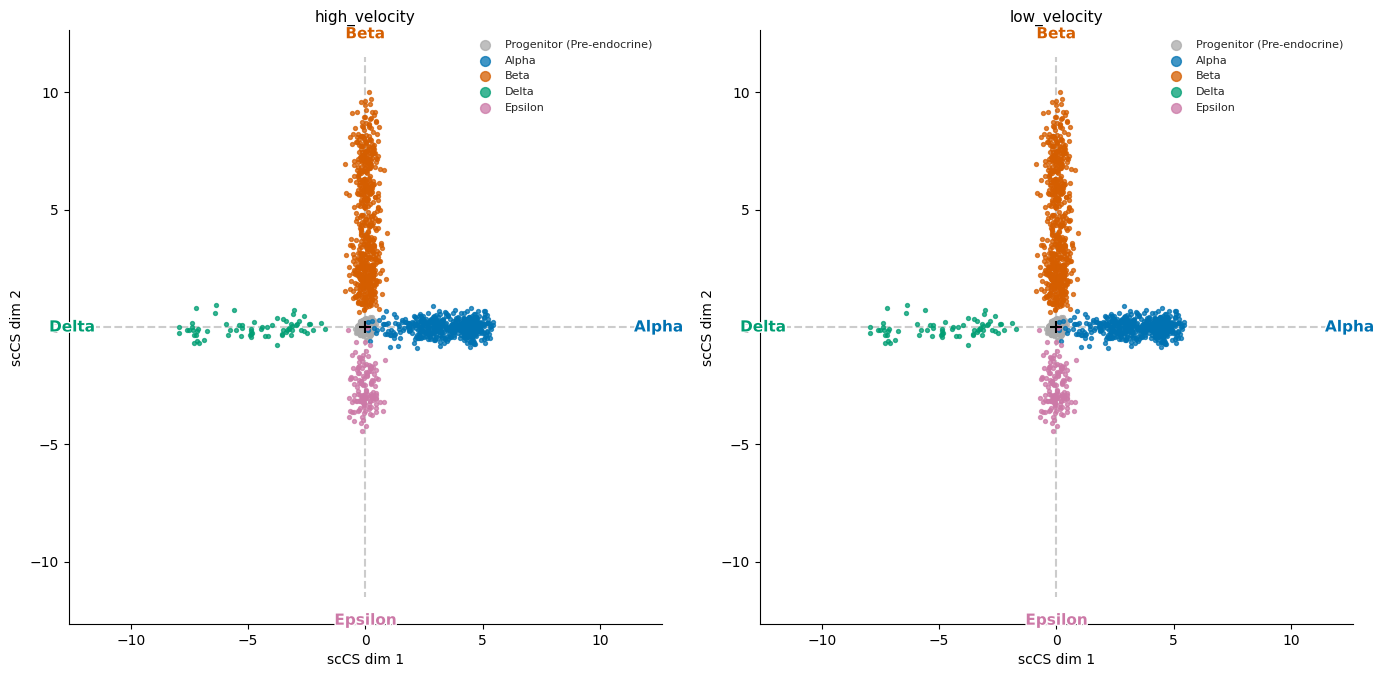

In [12]:
# Side-by-side star plots for each condition
# figsize_per_panel controls the size of each individual panel
fig = mscorer.plot_star_grid(
    results,
    figsize_per_panel=(7, 7),
)
plt.tight_layout()
plt.show()

### Tier 1b: Per-condition rose plots

`plot_rose_grid()` shows one polar rose plot per condition, all panels sharing the same
radial scale for direct magnitude comparison across conditions.


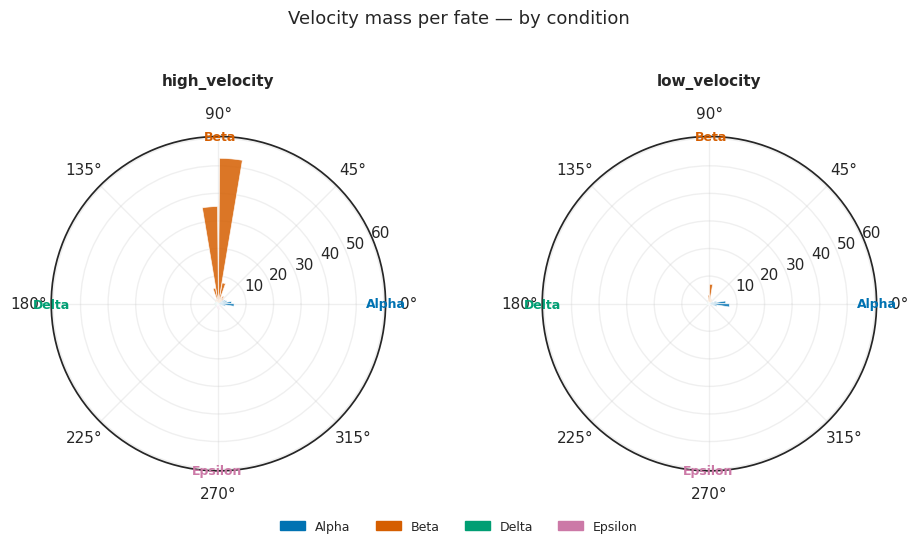

In [13]:
# Per-condition rose plots (shared radial scale)
fig = mscorer.plot_rose_grid(
    results,
    figsize_per_panel=(5, 5),
    title="Velocity mass per fate — by condition",
)
plt.tight_layout()
plt.show()


In [14]:
# Commitment vectors per condition
print("Commitment vectors (fraction of velocity mass per fate):")
for cond, res in results.items():
    print(f"\n  {cond}:")
    for fate, cv in zip(res.fate_names, res.commitment_vector):
        print(f"    {fate}: {cv:.3f}")

Commitment vectors (fraction of velocity mass per fate):

  high_velocity:
    Alpha: 0.149
    Beta: 0.727
    Delta: 0.066
    Epsilon: 0.058

  low_velocity:
    Alpha: 0.448
    Beta: 0.387
    Delta: 0.109
    Epsilon: 0.056


## Tier 2: Statistical comparison

### 2a. ΔCS with bootstrap confidence intervals

`compute_delta_CS()` computes ΔnCS = nCS_A − nCS_B for each fate pair,
with bootstrap CIs obtained by resampling cells within each condition.

A CI that does not include 0 indicates a statistically meaningful difference.


In [15]:
# Compute ΔCS: high_velocity − low_velocity
delta = mscorer.compute_delta_CS(
    condition_a="high_velocity",
    condition_b="low_velocity",
    n_bootstrap=500,
    ci=0.95,
    verbose=True,
)


=== ΔCS: 'high_velocity' − 'low_velocity' ===
  ΔnCS (point estimate):
         Alpha   Beta  Delta  Epsilon
Alpha    0.000  0.352  0.757    0.713
Beta    -3.504  0.000  1.403   -1.236
Delta     -inf   -inf  0.000     -inf
Epsilon -0.676  0.118  0.524    0.000

  95% CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    0.000  0.279  0.640    0.317
Beta    -4.659  0.000  1.210   -2.743
Delta      NaN    NaN  0.000      NaN
Epsilon -1.115  0.013  0.422    0.000

  95% CI high:
         Alpha   Beta  Delta  Epsilon
Alpha    0.000  0.425  0.921    1.070
Beta    -2.506  0.000  1.667   -0.106
Delta      NaN    NaN  0.000      NaN
Epsilon -0.259  0.209  0.654    0.000


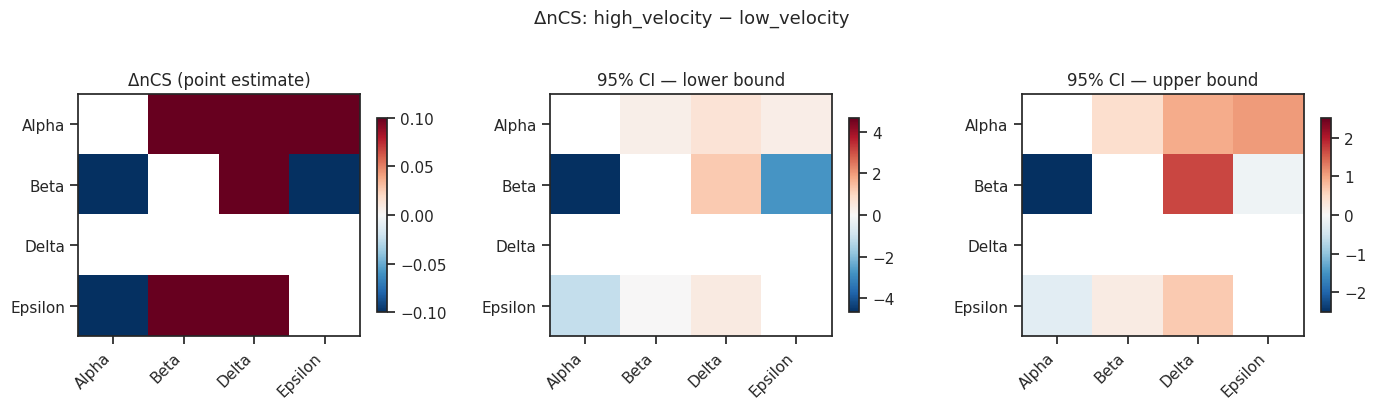

In [16]:
# Visualize ΔCS as a heatmap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fate_names = delta["fate_names"]
k = len(fate_names)
delta_mat = delta["delta_nCS"]
ci_low = delta["ci_low"]
ci_high = delta["ci_high"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, mat, title in zip(
    axes,
    [delta_mat, ci_low, ci_high],
    ["ΔnCS (point estimate)", "95% CI — lower bound", "95% CI — upper bound"]
):
    # Mask diagonal
    masked = np.where(np.eye(k, dtype=bool), np.nan, mat)
    vmax = np.nanmax(np.abs(masked))
    im = ax.imshow(masked, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(k)); ax.set_xticklabels(fate_names, rotation=45, ha="right")
    ax.set_yticks(range(k)); ax.set_yticklabels(fate_names)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("ΔnCS: high_velocity − low_velocity", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Identify fate pairs where CI excludes 0 (significant differences)
print("Fate pairs with significant ΔnCS (95% CI excludes 0):")
for i, fi in enumerate(fate_names):
    for j, fj in enumerate(fate_names):
        if i >= j:
            continue
        lo, hi = ci_low[i, j], ci_high[i, j]
        if lo > 0 or hi < 0:
            direction = "↑" if delta_mat[i, j] > 0 else "↓"
            print(f"  {fi} vs {fj}: Δ={delta_mat[i,j]:.3f} [{lo:.3f}, {hi:.3f}] {direction}")

Fate pairs with significant ΔnCS (95% CI excludes 0):
  Alpha vs Beta: Δ=0.352 [0.279, 0.425] ↑
  Alpha vs Delta: Δ=0.757 [0.640, 0.921] ↑
  Alpha vs Epsilon: Δ=0.713 [0.317, 1.070] ↑
  Beta vs Delta: Δ=1.403 [1.210, 1.667] ↑
  Beta vs Epsilon: Δ=-1.236 [-2.743, -0.106] ↓


### 2b. Permutation test on per-cell fate affinities

`compare_conditions()` tests whether per-cell fate affinity scores differ
significantly between conditions.

- **k=2 conditions**: permutation test (shuffle condition labels, recompute mean difference)
- **k>2 conditions**: Kruskal-Wallis + pairwise Mann-Whitney U with Bonferroni correction


In [18]:
# Statistical comparison of per-cell fate affinities
stats_df = mscorer.compare_conditions(
    results,
    test="auto",          # 'permutation' for k=2, 'kruskal' for k>2
    n_permutations=1000,
    pval_threshold=0.05,
    verbose=True,
)

print("\nStatistical comparison results:")
print(stats_df.to_string(index=False))


=== Condition comparison ===
  Test: auto  |  Significant results: 0 / 4
  No significant differences at pval_adj < 0.05.

Statistical comparison results:
   fate                    comparison           test  statistic  pval   mean_A   mean_B  pval_adj  significant
  Alpha high_velocity vs low_velocity kruskal-wallis        0.0   1.0 0.270815 0.270815       1.0        False
   Beta high_velocity vs low_velocity kruskal-wallis        0.0   1.0 0.312566 0.312566       1.0        False
  Delta high_velocity vs low_velocity kruskal-wallis        0.0   1.0 0.228806 0.228806       1.0        False
Epsilon high_velocity vs low_velocity kruskal-wallis        0.0   1.0 0.187813 0.187813       1.0        False


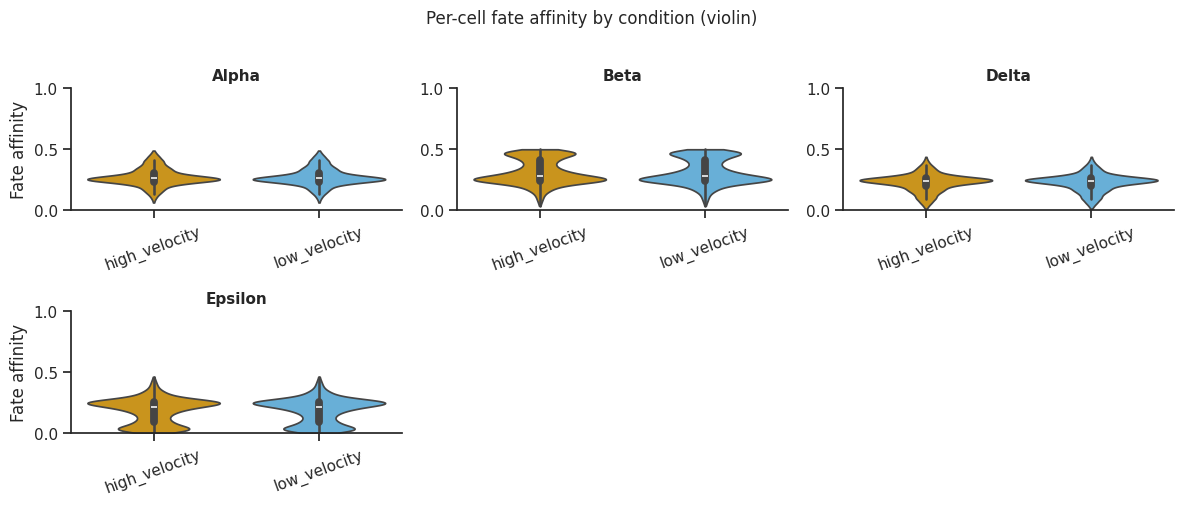

In [19]:
# Violin / box / strip plots of per-cell fate affinities
fig = mscorer.plot_affinity_distributions(
    results,
    plot_type="violin",   # 'violin', 'box', or 'strip'
    figsize=(12, 5),
)
plt.tight_layout()
plt.show()

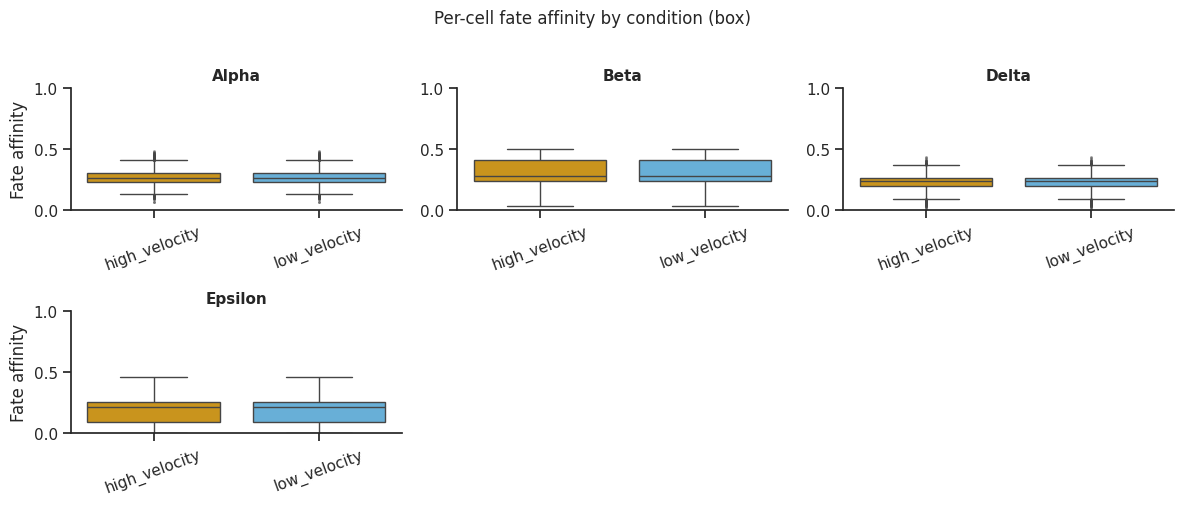

In [20]:
# Box plot version
fig = mscorer.plot_affinity_distributions(
    results,
    plot_type="box",
    figsize=(12, 5),
)
plt.tight_layout()
plt.show()

### 2c. Additional multi-condition visualizations

Three new plots for comparing commitment across conditions:

- **`plot_delta_cs_heatmap()`** — diverging heatmap of ΔnCS annotated with Δ ± CI
- **`plot_compare_conditions_bar()`** — grouped bar chart of nCS per condition per fate pair
- **`plot_commitment_vector_radar()`** — radar/spider chart of commitment vectors


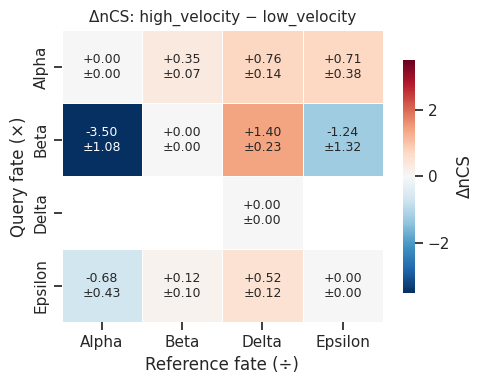

In [21]:
# ΔCS heatmap with CI annotation
fig = mscorer.plot_delta_cs_heatmap(
    delta,
    title="ΔnCS: high_velocity − low_velocity",
    figsize=(5, 4),
)
plt.tight_layout()
plt.show()


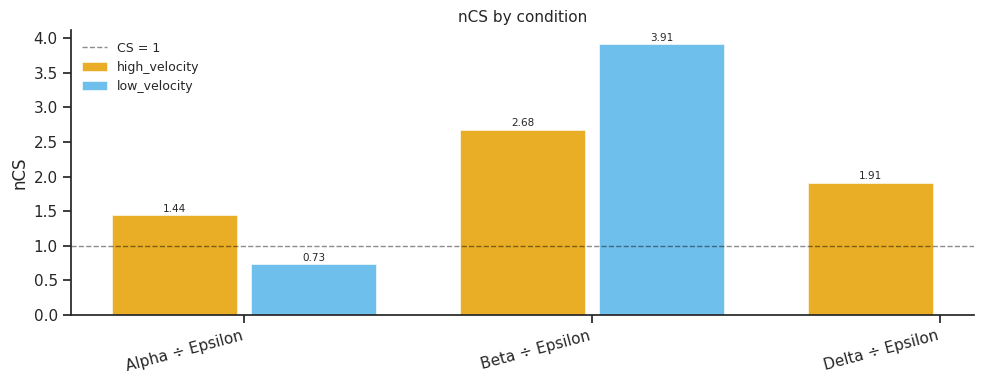

In [22]:
# Grouped bar chart: nCS per condition per fate pair
fig = mscorer.plot_compare_conditions_bar(
    results,
    title="nCS by condition",
    figsize=(10, 4),
)
plt.tight_layout()
plt.show()


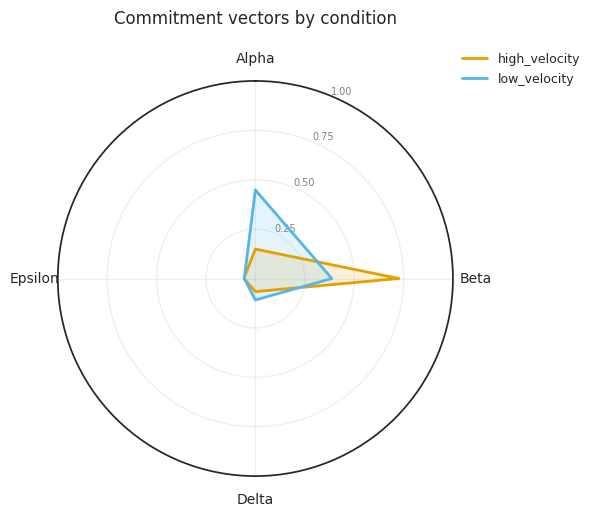

In [23]:
# Radar chart of commitment vectors (one polygon per condition)
# Falls back to bar chart for k < 3
fig = mscorer.plot_commitment_vector_radar(
    results,
    title="Commitment vectors by condition",
    figsize=(6, 6),
)
plt.tight_layout()
plt.show()


## Tier 3: Trajectory-level analysis

### 3a. Mixed linear model

`fit_mixed_model()` fits a linear mixed model (via statsmodels MixedLM) for each
fate arm:

```
affinity ~ condition  (fixed effect)
         + (1 | sample)  (random effect — accounts for replicate variation)
```

This is the most rigorous approach when you have biological replicates.


In [24]:
# Fit mixed model: condition fixed effect, sample random effect
try:
    lmm_results = mscorer.fit_mixed_model(
        results,
        replicate_key="sample",   # replicate column
        verbose=True,
    )

    print("\nMixed model results:")
    print(lmm_results.to_string(index=False))
except Exception as e:
    print(f"Mixed model skipped (requires statsmodels): {e}")


=== Mixed-effects model results ===
  Significant effects: 0 / 4

Mixed model results:
   fate    condition     reference          coef  std_err       z_score  pval    ci_low  ci_high  pval_adj  significant
  Alpha low_velocity high_velocity -3.254918e-19 0.002280 -1.427620e-16   1.0 -0.004469 0.004469       1.0        False
   Beta low_velocity high_velocity -1.775410e-18 0.003320 -5.346931e-16   1.0 -0.006508 0.006508       1.0        False
  Delta low_velocity high_velocity -1.220594e-18 0.002279 -5.354918e-16   1.0 -0.004468 0.004468       1.0        False
Epsilon low_velocity high_velocity  3.030033e-16 0.003302  9.177422e-14   1.0 -0.006471 0.006471       1.0        False


### 3b. Trajectory shift analysis

`trajectory_shift()` tests whether the **pseudotime distribution** along each fate arm
differs between conditions using:
- **Kolmogorov-Smirnov (KS) test** — detects any distributional difference
- **Wasserstein distance** — quantifies the magnitude of the shift, with bootstrap CI

A significant KS test + large Wasserstein distance indicates that cells in one condition
are systematically further along (or earlier in) the differentiation trajectory.


In [25]:
# Trajectory shift analysis
# Returns a DataFrame with columns: fate, comparison, ks_stat, ks_pval,
# wasserstein, wasserstein_ci_low, wasserstein_ci_high, mean_pt_A, mean_pt_B,
# delta_mean_pt, significant
try:
    shift_df = mscorer.trajectory_shift(
        results,
        n_bootstrap=500,
        verbose=True,
    )

    print("\nTrajectory shift summary:")
    print(shift_df[["fate", "comparison", "ks_stat", "ks_pval",
                     "wasserstein", "wasserstein_ci_low", "wasserstein_ci_high",
                     "significant"]].to_string(index=False))
except Exception as e:
    print(f"Trajectory shift skipped: {e}")
    shift_df = None


=== Trajectory shift analysis ===
  Significant shifts: 3 / 3
   fate                    comparison  ks_stat  ks_pval_adj  wasserstein  delta_mean_pt
  Alpha high_velocity vs low_velocity 0.171245     0.005030     0.002727      -0.002664
   Beta high_velocity vs low_velocity 0.246261     0.034612     0.014225       0.012765
Epsilon high_velocity vs low_velocity 0.481026     0.000210     0.003927      -0.003627

Trajectory shift summary:
   fate                    comparison  ks_stat  ks_pval  wasserstein  wasserstein_ci_low  wasserstein_ci_high  significant
  Alpha high_velocity vs low_velocity 0.171245 0.001677     0.002727            0.001802             0.004006         True
   Beta high_velocity vs low_velocity 0.246261 0.011537     0.014225            0.012215             0.018473         True
Epsilon high_velocity vs low_velocity 0.481026 0.000070     0.003927            0.002510             0.006638         True


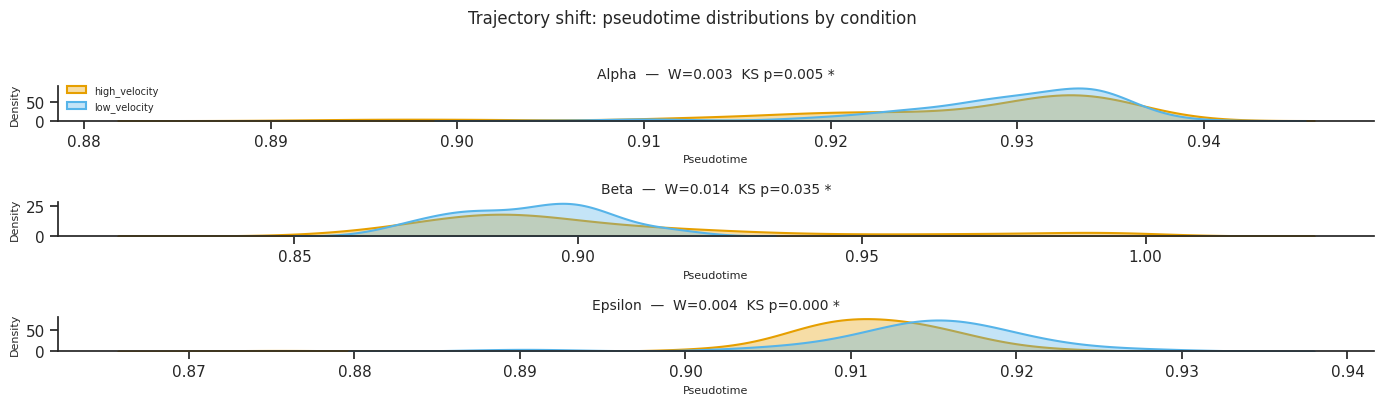

In [26]:
# KDE plots of pseudotime distributions per fate per condition
try:
    if shift_df is not None:
        fig = mscorer.plot_trajectory_shift(
            shift_df,
            figsize=(14, 4),
        )
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Trajectory shift plot skipped: {e}")

## 6. Driver genes per condition

Identify fate-driving genes (velocity-based, DEG-based, velocity-fate correlation)
**within each condition**. Use the shared `adata_sub` per condition, then assemble
the results into one tidy table with `(condition, fate)` columns.

This is the standard way to find genes whose role in commitment changes
between conditions: a gene that is a top driver in `low_velocity` but not
in `high_velocity` is a candidate condition-specific regulator.

In [27]:
# Velocity-based drivers — run per condition
from scCS.drivers import get_velocity_drivers

adata_sub_shared = mscorer._scorer.adata_sub
fate_names = mscorer._scorer._fate_map.fate_names
root_cluster = mscorer._scorer.root
obs_key_used = mscorer._scorer.obs_key

vel_drivers_per_cond = {}
for cond in mscorer.conditions:
    mask = (adata_sub_shared.obs[mscorer.condition_obs_key].astype(str) == cond).values
    sub = adata_sub_shared[mask].copy()
    vel_drivers_per_cond[cond] = get_velocity_drivers(
        sub, fate_names=fate_names, obs_key=obs_key_used,
        root=root_cluster, n_top_genes=20,
    )

# Compact long-form table
print("Top velocity drivers (top 5 per fate, per condition):")
_stack_drivers_by_condition(
    vel_drivers_per_cond, n_per_fate=5,
    cols=["gene", "mean_velocity", "rank"],
)


── Velocity drivers: Alpha (top 20, sorted by delta_velocity) ──
 rank    gene  delta_velocity  mean_velocity
    1     Clu        2.394982       2.601254
    2    Ghrl        2.230801       1.208408
    3  Btbd17        1.361021       1.130396
    4  Cryba2        1.165649       1.429237
    5    Cpa2        0.996341       0.808371
    6  Tm4sf4        0.752253       0.572645
    7  Npepl1        0.701914       0.203834
    8     Hn1        0.642953       0.173084
    9    Pax6        0.628259       0.938433
   10   Meis2        0.613610       0.691767
   11    Vasp        0.563599       0.066359
   12 Lurap1l        0.551248       0.355268
   13   Rgs17        0.542472       0.575468
   14   Celf3        0.540257       0.375474
   15    Tox3        0.529739       0.308918
   16   Cd200        0.518199       0.406608
   17  Ppp3ca        0.514993       0.219860
   18    Pax4        0.478970       0.058572
   19    Cpt2        0.421590       0.253768
   20 Smarcd2        0.420897     

,condition,fate,gene,mean_velocity,rank
0,high_velocity,Alpha,Clu,2.601254,1
1,high_velocity,Alpha,Ghrl,1.208408,2
2,high_velocity,Alpha,Btbd17,1.130396,3
3,high_velocity,Alpha,Cryba2,1.429237,4
4,high_velocity,Alpha,Cpa2,0.808371,5
...,...,...,...,...,...
30,low_velocity,Epsilon,Isl1,0.430871,1
31,low_velocity,Epsilon,Meis2,1.057928,2
32,low_velocity,Epsilon,Pax4,0.539212,3
33,low_velocity,Epsilon,Clu,1.044996,4


In [28]:
# DEG-based drivers — run per condition
from scCS.drivers import get_deg_drivers

deg_drivers_per_cond = {}
for cond in mscorer.conditions:
    mask = (adata_sub_shared.obs[mscorer.condition_obs_key].astype(str) == cond).values
    sub = adata_sub_shared[mask].copy()
    deg_drivers_per_cond[cond] = get_deg_drivers(
        sub, fate_names=fate_names, obs_key=obs_key_used,
        root=root_cluster, n_top_genes=20,
        pval_threshold=0.05, logfc_threshold=0.25,
    )

print("Top DEG drivers (top 5 per fate, per condition):")
_stack_drivers_by_condition(
    deg_drivers_per_cond, n_per_fate=5,
    cols=["gene", "logfoldchange", "pval_adj", "pct_fate", "pct_progenitor"],
)


── DEG drivers: Alpha vs progenitor ──
   Significant: 531  (up: 251, down: 280)
   gene  logfoldchange     pval_adj  pct_fate  pct_progenitor
    Gcg     270.465210 1.082532e-38  0.735577             NaN
    Pyy     168.419342 2.504105e-31  0.961538             NaN
   Iapp     103.014679 1.340236e-46  0.855769             NaN
    Ttr      72.689537 6.161996e-51  1.000000             NaN
   Gnas      36.008827 8.249209e-28  1.000000             NaN
   Rbp4      32.906731 1.717601e-17  0.942308             NaN
Slc38a5      19.159832 4.085392e-32  0.903846             NaN
 Tmem27      15.835037 5.708899e-60  0.971154             NaN
 Pcsk1n      14.708415 1.348048e-36  0.995192             NaN
   Gast      10.758981 8.631471e-15  0.548077             NaN
    Cpe       8.463097 1.488365e-23  1.000000             NaN
  Pcsk2       7.870811 5.754125e-33  0.841346             NaN
   Gpx3       7.583188 3.834793e-39  0.937500             NaN
    Ppy       6.445889 2.303623e-07  0.408654     

,condition,fate,gene,logfoldchange,pval_adj,pct_fate,pct_progenitor
0,high_velocity,Alpha,Gcg,270.465210,1.082532e-38,0.735577,NaN
1,high_velocity,Alpha,Pyy,168.419342,2.504105e-31,0.961538,NaN
2,high_velocity,Alpha,Iapp,103.014679,1.340236e-46,0.855769,NaN
3,high_velocity,Alpha,Ttr,72.689537,6.161996e-51,1.000000,NaN
4,high_velocity,Alpha,Gnas,36.008827,8.249209e-28,1.000000,NaN
...,...,...,...,...,...,...,...
30,low_velocity,Epsilon,Ghrl,586.200867,2.348411e-13,1.000000,NaN
31,low_velocity,Epsilon,Pyy,73.462746,2.327392e-05,0.840000,NaN
32,low_velocity,Epsilon,Rbp4,54.519619,1.337757e-09,1.000000,NaN
33,low_velocity,Epsilon,Lrpprc,48.062851,6.402959e-07,0.880000,NaN


In [29]:
# Driver overlap between conditions: which genes are shared vs unique per fate?
def _driver_overlap(per_cond_drivers, n_top=10, gene_col="gene"):
    """Build a fate x gene x condition presence matrix from {cond: {fate: df}}.

    Defensive: missing fates / missing gene columns / empty DataFrames yield empty sets.
    """
    rows = []
    conds = list(per_cond_drivers.keys())
    if not conds:
        return pd.DataFrame()
    # Union of fates across all conditions (don't assume identical fate sets)
    fates = sorted({f for d in per_cond_drivers.values() for f in d.keys()})
    for fate in fates:
        sets = {}
        for cond in conds:
            df = per_cond_drivers[cond].get(fate)
            if df is None or len(df) == 0 or gene_col not in df.columns:
                sets[cond] = set()
            else:
                sets[cond] = set(df.head(n_top)[gene_col].astype(str))
        all_genes = sorted(set.union(*sets.values())) if sets else []
        for g in all_genes:
            row = {"fate": fate, "gene": g}
            for cond in conds:
                row[cond] = g in sets[cond]
            row["n_conds"] = sum(row[cond] for cond in conds)
            row["shared_all"] = row["n_conds"] == len(conds)
            rows.append(row)
    return pd.DataFrame(rows)

overlap_df = _driver_overlap(vel_drivers_per_cond, n_top=10)
print(f"Top-10 velocity driver overlap (per fate, {len(mscorer.conditions)} conditions):")
overlap_df.head(20)


Top-10 velocity driver overlap (per fate, 2 conditions):


,fate,gene,high_velocity,low_velocity,n_conds,shared_all
0,Alpha,Btbd17,True,False,1,False
1,Alpha,Clu,True,True,2,True
2,Alpha,Cpa2,True,True,2,True
3,Alpha,Cryba2,True,True,2,True
4,Alpha,Ghrl,True,False,1,False
5,Alpha,Hn1,True,False,1,False
6,Alpha,Krt7,False,True,1,False
7,Alpha,Meis2,True,True,2,True
8,Alpha,Npepl1,True,True,2,True
9,Alpha,Pax4,False,True,1,False


## 7. Pathway enrichment per condition

Run `get_enrichment` per condition on the DEG drivers computed above.
Display top pathways per `(condition, fate, direction)` in a single
compact table.

> Requires `gseapy` and internet access for the Enrichr API. Wrapped in
> try/except so the notebook still builds offline.

In [30]:
# Pathway enrichment — run per condition on the DEG drivers from §6
from scCS.enrichment import run_enrichment_per_fate

enrichment_per_cond = {}
for cond in mscorer.conditions:
    try:
        enrichment_per_cond[cond] = run_enrichment_per_fate(
            deg_drivers=deg_drivers_per_cond[cond],
            fate_names=fate_names,
            organism="mouse",
            pval_threshold=0.05,
            logfc_threshold=0.25,
            plot=False,
            n_top_pathways=10,
        )
    except ImportError:
        print("gseapy not installed. Run: pip install gseapy")
        break
    except Exception as e:
        print(f"Enrichment for '{cond}' skipped: {e}")
        enrichment_per_cond[cond] = {}

# Compact summary across conditions
enrich_df = _stack_enrichment_by_condition(enrichment_per_cond, n_per_group=3)
if not enrich_df.empty:
    keep = ["condition", "fate", "direction", "Gene_set", "Term",
            "Overlap", "Adjusted P-value"]
    keep = [c for c in keep if c in enrich_df.columns]
    display(enrich_df[keep])
else:
    print("(No enriched terms — common with small datasets / few significant DEGs.)")


  Pathway enrichment: Alpha
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 251
  Down-regulated genes: 280

  [up] Significant terms: 61
                  Gene_set                                         Term Overlap  Adjusted P-value
           KEGG_2019_Mouse  Protein processing in endoplasmic reticulum  14/163          0.000004
           KEGG_2019_Mouse                    Thyroid hormone synthesis    9/73          0.000032
           KEGG_2019_Mouse                        Circadian entrainment    8/99          0.001974
           KEGG_2019_Mouse                       Gastric acid secretion    7/74          0.001974
           KEGG_2019_Mouse                                     Lysosome   8/124          0.006893
GO_Biological_Process_2021 regulation of insulin secretion (GO:0050796)   9/104          0.010186
           KEGG_2019_Mouse                         Dopaminergic synapse   8/135          0.010271
           KEGG_2019_

,condition,fate,direction,Gene_set,Term,Overlap,Adjusted P-value
0,high_velocity,Alpha,up,KEGG_2019_Mouse,Protein processing in endoplasmic reticulum,14/163,3.822697e-06
1,high_velocity,Alpha,up,KEGG_2019_Mouse,Thyroid hormone synthesis,9/73,3.211278e-05
2,high_velocity,Alpha,up,KEGG_2019_Mouse,Circadian entrainment,8/99,1.973558e-03
3,high_velocity,Beta,up,KEGG_2019_Mouse,Protein processing in endoplasmic reticulum,22/163,4.044027e-11
4,high_velocity,Beta,up,GO_Biological_Process_2021,IRE1-mediated unfolded protein response (GO:00...,12/53,2.514449e-07
...,...,...,...,...,...,...,...
25,low_velocity,Beta,down,Reactome_2022,Peptide Chain Elongation R-HSA-156902,18/86,7.313322e-22
26,low_velocity,Beta,down,Reactome_2022,Eukaryotic Translation Elongation R-HSA-156842,18/90,7.313322e-22
27,low_velocity,Epsilon,down,GO_Biological_Process_2021,cytoplasmic translation (GO:0002181),29/93,2.964622e-44
28,low_velocity,Epsilon,down,GO_Biological_Process_2021,SRP-dependent cotranslational protein targetin...,28/90,7.196346e-43


## 8. Expression trends along fate arms — per condition

`plot_expression_trends` orders cells by per-cell fate affinity (or
pseudotime / radial distance) and plots smoothed expression of each gene.

Run it **per condition side by side** to see whether a marker's expression
trajectory differs between conditions — e.g. earlier onset, higher peak,
delayed shutdown.

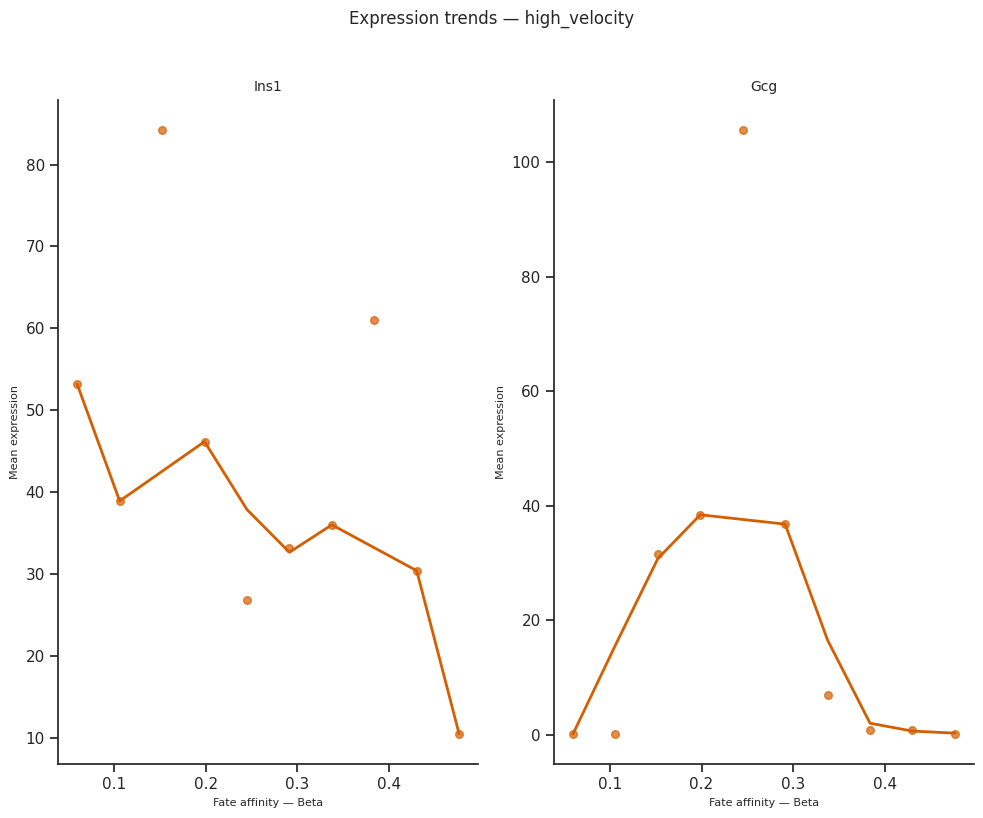

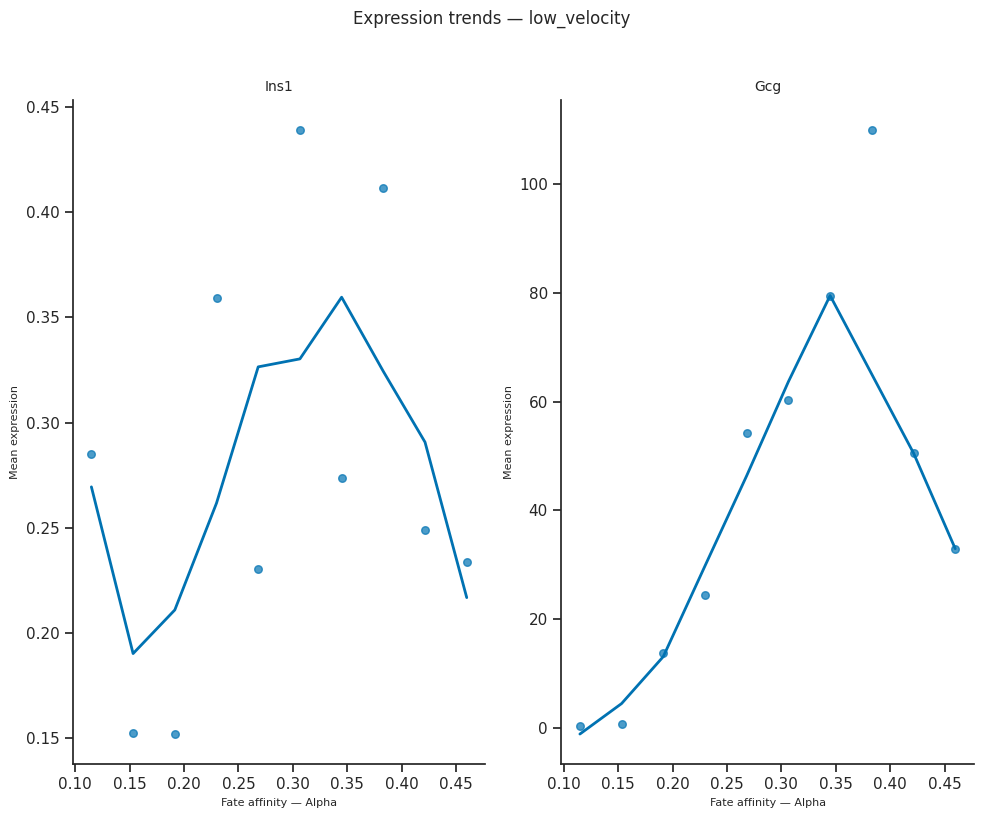

In [31]:
# Expression trends, two markers, side-by-side per condition
from scCS.plot import plot_expression_trends

genes_of_interest = ["Ins1", "Gcg"]  # Beta and Alpha markers
genes_of_interest = [g for g in genes_of_interest if g in adata_sub_shared.var_names]
assert genes_of_interest, "None of the requested markers are in the pancreas var_names"

for cond in mscorer.conditions:
    mask = (adata_sub_shared.obs[mscorer.condition_obs_key].astype(str) == cond).values
    sub = adata_sub_shared[mask].copy()
    try:
        fig = plot_expression_trends(
            sub, results[cond],
            genes=genes_of_interest,
            x_axis="affinity",
            figsize=(10, 4 * len(genes_of_interest)),
        )
        fig.suptitle(f"Expression trends — {cond}", y=1.02, fontsize=12)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"plot_expression_trends failed for '{cond}': {e}")

## 9. Transfer labels to full adata

`transfer_labels()` writes per-cell scores from the shared embedding back to the
full adata.  This is identical to the single-condition workflow.


[scCS] Labels transferred to adata.obs for 1876 / 3696 cells. Columns: ['cs_high_velocity_Alpha', 'cs_high_velocity_Beta', 'cs_high_velocity_Delta', 'cs_high_velocity_Epsilon', 'cs_high_velocity_dominant_fate', 'cs_high_velocity_entropy']
[scCS] Labels transferred to adata.obs for 1876 / 3696 cells. Columns: ['cs_low_velocity_Alpha', 'cs_low_velocity_Beta', 'cs_low_velocity_Delta', 'cs_low_velocity_Epsilon', 'cs_low_velocity_dominant_fate', 'cs_low_velocity_entropy']
Columns added to adata.obs: ['cs_high_velocity_Alpha', 'cs_high_velocity_Beta', 'cs_high_velocity_Delta', 'cs_high_velocity_Epsilon', 'cs_high_velocity_dominant_fate', 'cs_high_velocity_entropy', 'cs_high_velocity_nn_entropy', 'cs_low_velocity_Alpha'] ...


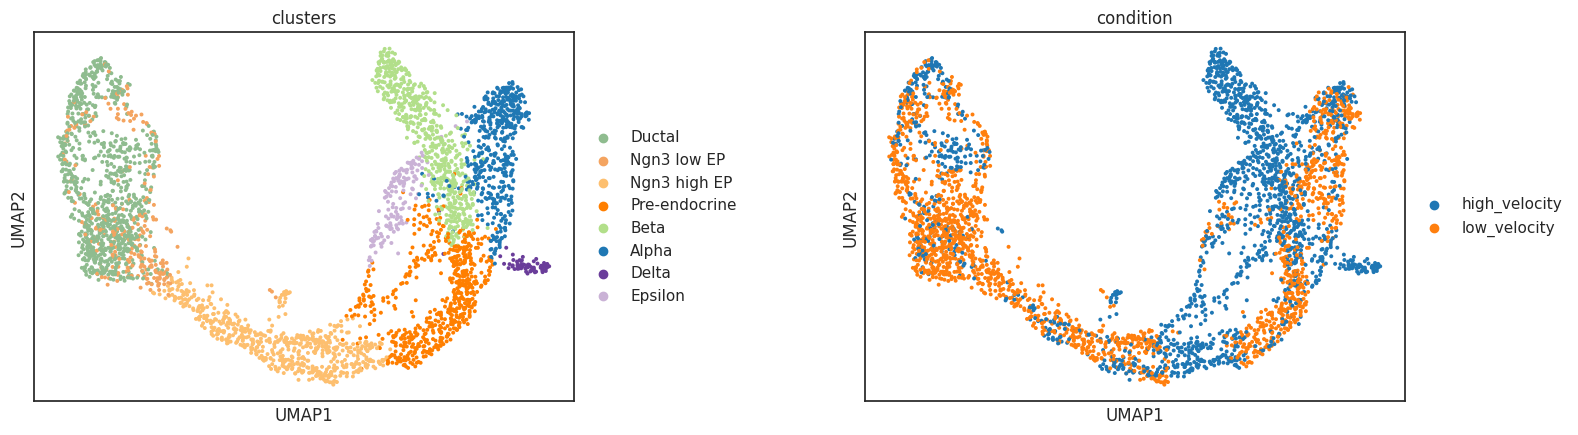

In [32]:
# Transfer per-cell scores to full adata for all conditions
# PairScorer.transfer_labels writes condition-specific columns:
# e.g., cs_high_velocity_Alpha, cs_low_velocity_Alpha, etc.
mscorer.transfer_labels(results, prefix="cs_")

# Columns added to adata.obs
cs_cols = [c for c in adata.obs.columns if c.startswith("cs_")]
print("Columns added to adata.obs:", cs_cols[:8], "...")

# Visualize on UMAP
sc.pl.umap(adata, color=["clusters", "condition"], ncols=2, wspace=0.4)

high_velocity: mean entropy = 0.936 ± 0.063
low_velocity: mean entropy = 0.936 ± 0.063


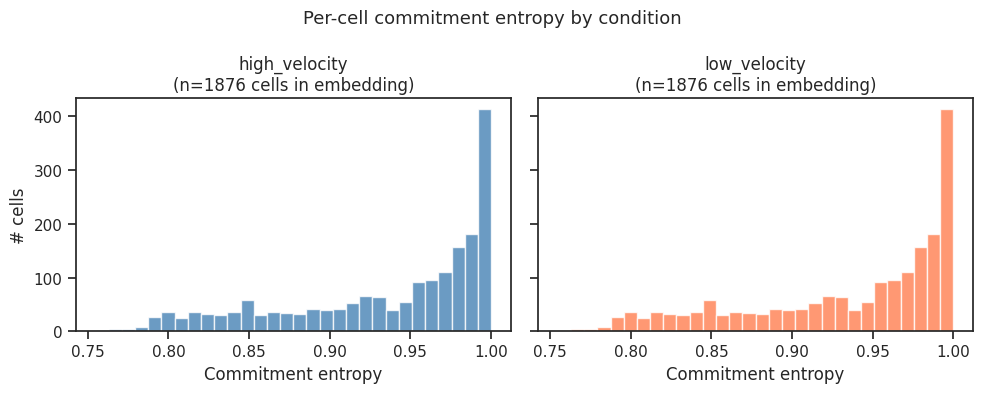

In [33]:
# Compare entropy distributions between conditions
# After transfer_labels, columns are named cs_{condition}_{fate}
# For entropy, use the per-condition results directly from adata_sub

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
colors = {"high_velocity": "steelblue", "low_velocity": "coral"}

for ax, cond in zip(axes, ["high_velocity", "low_velocity"]):
    # Get entropy from the condition-specific result
    res = results[cond]
    if res.cell_scores is not None:
        # Compute per-cell entropy from cell_scores
        k = res.cell_scores.shape[1]
        with np.errstate(divide="ignore", invalid="ignore"):
            log_s = np.where(res.cell_scores > 0, np.log(res.cell_scores), 0.0)
        ent = -np.sum(res.cell_scores * log_s, axis=1) / np.log(k)
        ax.hist(ent, bins=30, color=colors[cond], edgecolor="white", alpha=0.8)
        ax.set_title(f"{cond}\n(n={len(ent)} cells in embedding)")
        ax.set_xlabel("Commitment entropy")
        print(f"{cond}: mean entropy = {ent.mean():.3f} ± {ent.std():.3f}")
    else:
        ax.set_title(f"{cond}\n(no cell-level scores)")

axes[0].set_ylabel("# cells")
plt.suptitle("Per-cell commitment entropy by condition", fontsize=13)
plt.tight_layout()
plt.show()

## Summary — scCS pairwise workflow

```python
import scCS

# 1. Add condition column to adata.obs (or use existing one)
adata.obs["condition"] = ...   # e.g., 'control', 'treated'
adata.obs["sample"] = ...      # biological replicates

# 2. Initialize PairScorer
mscorer = scCS.PairScorer(
    adata,
    root="Ductal",
    branches=["Alpha", "Beta", "Delta", "Epsilon"],
    condition_obs_key="condition",
    obs_key="clusters",
)

# 3. Build SHARED embedding on pooled data
mscorer.build_embedding(ordering_metric="pseudotime")
mscorer.refit_pseudotime(scale_01=False)  # preserve ordering
mscorer.fit()

# ── Tier 1: Score each condition ──────────────────────────────────────────────
results = mscorer.score_all_conditions(cell_level=True, n_bootstrap=200)
mscorer.plot_star_grid(results)
mscorer.plot_rose_grid(results)                    # per-condition rose plots

# ── Tier 2: Statistical comparison ───────────────────────────────────────────
delta = mscorer.compute_delta_CS("treated", "control", n_bootstrap=500)
stats = mscorer.compare_conditions(results, n_permutations=1000)
mscorer.plot_affinity_distributions(results, plot_type="violin")

# ── Tier 3: Trajectory-level analysis ────────────────────────────────────────
lmm   = mscorer.fit_mixed_model(results, replicate_key="sample")
shift = mscorer.trajectory_shift(results, n_bootstrap=500)
mscorer.plot_trajectory_shift(shift)

# ── Downstream §6: Driver genes per condition ────────────────────────────────
# Loop conditions: mask adata_sub per condition, call get_velocity_drivers /
# get_deg_drivers, then collect into one (condition, fate, gene) table.

# ── Downstream §7: Pathway enrichment per condition ──────────────────────────
# Loop conditions: call run_enrichment_per_fate on the per-condition DEG
# drivers, collect into one (condition, fate, direction, Term) table.

# ── Downstream §8: Expression trends per condition ───────────────────────────
# Loop conditions: call plot_expression_trends on the masked adata_sub plus
# results[cond] for side-by-side per-condition trajectories.

# ── Transfer per-cell labels back to full adata for UMAP / downstream ────────
mscorer.transfer_labels(adata, results)
```

### Interpretation guide

| Result | Interpretation |
|--------|---------------|
| ΔnCS > 0, CI excludes 0 | Condition A has stronger commitment toward that fate pair |
| Permutation p < 0.05 | Per-cell fate affinities differ significantly between conditions |
| LMM condition coefficient significant | Condition effect on fate affinity, controlling for replicate |
| KS p < 0.05 + large Wasserstein | Cells in one condition are systematically further along the trajectory |
| Top driver gene present in one condition only | Condition-specific regulator candidate |
| Pathway enriched in one condition only | Differentially activated pathway |
| Expression trend earlier/later in one condition | Shifted developmental timing for that gene |

For **single-condition analysis**, see `Single Condition Analysis.ipynb`.
For **3+ condition analysis**, see `Multiple Comparison Analysis.ipynb`.
